# Running the analysis for 16 Europen capitals

This notebook computes amenity complexity for 16 European capital cities and calculates spatial autocorrelation statistics (Moran's I and Geary's C) for a standardized 20x20km core area.

Refinements:
- **Center**: Weighted mean of amenity locations (gravity center).
- **Winsorization**: 5% / 95% clipping (approx) via (0.05, 0.05) limits.
- **Projection**: Plots are reprojected to EPSG:3035 (LAEA Europe) to appear as true 20x20km squares.

In [1]:
import warnings
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
import esda
import libpysal
from libpysal.weights import KNN
from scipy.stats.mstats import winsorize
import h3

import amenity_complexity as amc
from amenity_complexity.geo import load_fuas, bbox_from_fua, pois_to_h3, h3_to_polygon
from amenity_complexity.io import pois_from_foursquare, pois_from_overture
from amenity_complexity.core import compute_complexity

# Settings
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore', category=UserWarning, module='libpysal')
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Load FUAs
fua_path = "../data/GHS_FUA_UCDB2015_GLOBE_R2019A_54009_1K_V1_0.gpkg" 
try:
    fuas = load_fuas(fua_path)
except Exception as e:
    print(f"Could not load FUA file: {e}")
    fuas = None

In [5]:
COUNTRIES = [
    "GBR", "FRA", "DEU", "ESP", "ITA", "AUT", "NLD", "BEL", "PRT", "SWE", "NOR", "FIN", "DNK", "IRL", "POL", "CZE"
]

CITIES = [
    "London", "Paris", "Berlin", "Madrid", 
    "Rome", "Vienna", "Amsterdam", "Brussels", 
    "Lisbon", "Stockholm", "Oslo", "Helsinki", 
    "Copenhagen", "Dublin", "Warsaw", "Prague"
]

In [8]:
for i, (country, city_name) in enumerate(zip(COUNTRIES, CITIES)):
    print(f"Processing {city_name}, {country}...")
    
    try:
        # 1. Get Initial BBox from FUA
        if fuas is not None:
            subset = fuas[(fuas['eFUA_name'].astype(str).str.contains(city_name, case=False)) & (fuas['Cntry_ISO'] == country)]
            if subset.empty:
                ax.text(0.5, 0.5, f"{city_name}\nNot found", ha='center')
                continue
            row = subset.iloc[0]
            fua_id = str(row['eFUA_ID'])
            bbox = bbox_from_fua(fuas, 'eFUA_ID', fua_id, buffer_m=5000)
        else:
            ax.text(0.5, 0.5, f"{city_name}\nNo FUA data", ha='center')
            continue

        # 2. Fetch POIs
        pois = pois_from_overture(bbox=bbox, trim_cols=True)
        if pois.empty:
            ax.text(0.5, 0.5, f"{city_name}\nNo POIs", ha='center')
            continue

    except Exception as e:
        print(f"Error processing {city_name}: {e}")
        ax.text(0.5, 0.5, f"{city_name}\nError", ha='center')
        continue

    print(f"Fetched {len(pois)} POIs")

Processing London...
Fetched 6653 POIs
Processing Paris...
Fetched 357711 POIs
Processing Berlin...
Fetched 176222 POIs
Processing Madrid...
Fetched 202616 POIs
Processing Rome...
Fetched 173626 POIs
Processing Vienna...
Fetched 102281 POIs
Processing Amsterdam...
Fetched 124186 POIs
Processing Brussels...
Fetched 129266 POIs
Processing Lisbon...
Fetched 106861 POIs
Processing Stockholm...
Fetched 85497 POIs
Processing Oslo...
Fetched 68486 POIs
Processing Helsinki...
Fetched 60308 POIs
Processing Copenhagen...
Fetched 101612 POIs
Processing Dublin...
Fetched 58855 POIs
Processing Warsaw...
Fetched 133921 POIs
Processing Prague...
Fetched 102803 POIs


In [12]:
for i, (country, city_name) in enumerate(zip(COUNTRIES, CITIES)):
    subset = fuas[(fuas['eFUA_name'].astype(str).str.contains(city_name, case=False)) & (fuas['Cntry_ISO'] == country)]
    row = subset.sort_values('FUA_p_2015', ascending=False)
    row = row.iloc[0]
    print(row)


eFUA_ID                                                  5288.0
UC_num                                                     12.0
UC_IDs        1892;1895;1906;1912;1914;1924;1936;1945;1948;1...
eFUA_name                                                London
Commuting                                                   1.0
Cntry_ISO                                                   GBR
Cntry_name                                        UnitedKingdom
FUA_area                                                 6605.0
UC_area                                                  2219.0
FUA_p_2015                                      12598186.448313
UC_p_2015                                       10765369.599459
Com_p_2015                                       1832816.848854
geometry      MULTIPOLYGON (((0.2563626544052783 51.91001247...
Name: 8453, dtype: object
eFUA_ID                                                  2702.0
UC_num                                                      2.0
UC_IDs        

Starting processing (EPSG:3035 Projection)...
Processing London...
Fetched 827330 POIs
Processing Paris...
Fetched 357711 POIs
Processing Berlin...
Fetched 176222 POIs
Processing Madrid...
Fetched 202616 POIs
Processing Rome...
Fetched 173626 POIs
Processing Vienna...
Fetched 102281 POIs
Processing Amsterdam...
Fetched 124186 POIs
Processing Brussels...
Fetched 129266 POIs
Processing Lisbon...
Fetched 106861 POIs
Processing Stockholm...
Fetched 85497 POIs
Processing Oslo...
Fetched 68486 POIs
Processing Helsinki...
Fetched 60308 POIs
Processing Copenhagen...
Fetched 101612 POIs
Processing Dublin...
Fetched 58855 POIs
Processing Warsaw...
Fetched 133921 POIs
Processing Prague...
Fetched 102803 POIs


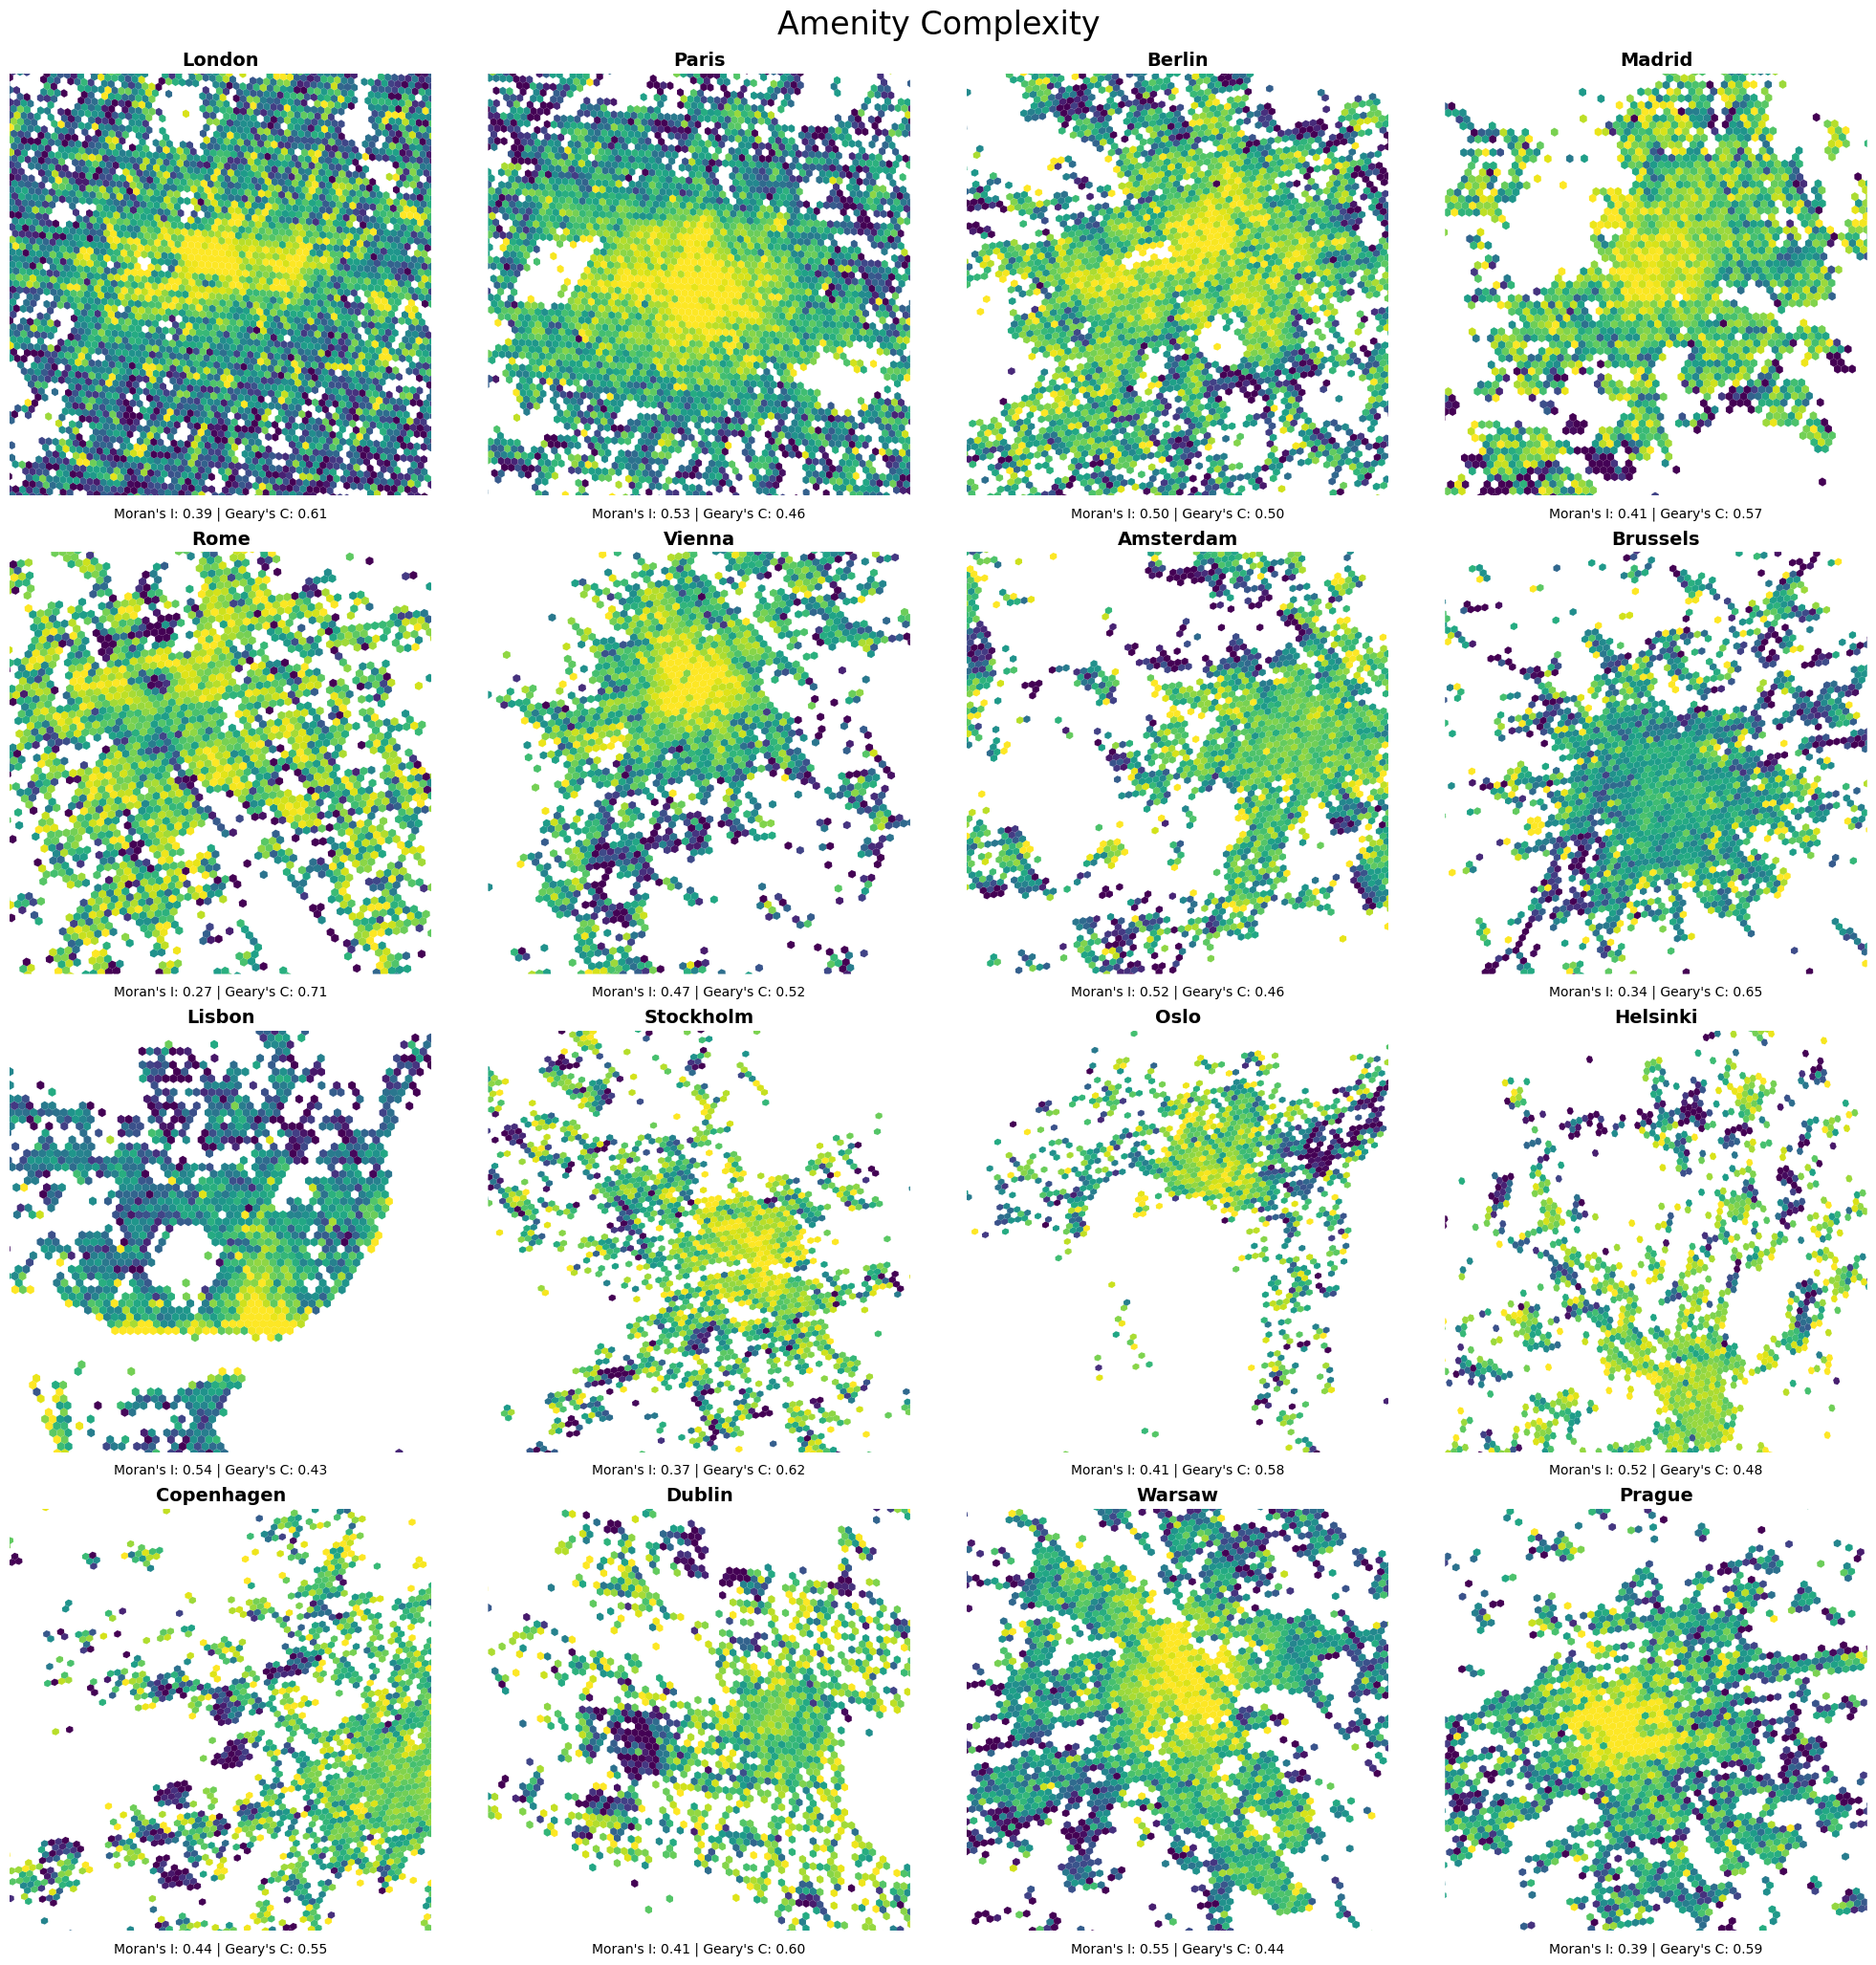

In [17]:
def get_weighted_center(units_df, lat_col='lat', lon_col='lon', weight_col='n_amenities'):
    """Compute the weighted mean center of the units."""
    if weight_col not in units_df.columns:
        return units_df[lat_col].mean(), units_df[lon_col].mean()
        
    total_weight = units_df[weight_col].sum()
    if total_weight == 0:
        return units_df[lat_col].mean(), units_df[lon_col].mean()
        
    w_lat = (units_df[lat_col] * units_df[weight_col]).sum() / total_weight
    w_lon = (units_df[lon_col] * units_df[weight_col]).sum() / total_weight
    return w_lat, w_lon

COUNTRIES = [
    "GBR", "FRA", "DEU", "ESP", "ITA", "AUT", "NLD", "BEL", "PRT", "SWE", "NOR", "FIN", "DNK", "IRL", "POL", "CZE"
]

CITIES = [
    "London", "Paris", "Berlin", "Madrid", 
    "Rome", "Vienna", "Amsterdam", "Brussels", 
    "Lisbon", "Stockholm", "Oslo", "Helsinki", 
    "Copenhagen", "Dublin", "Warsaw", "Prague"
]

results = {}
H3_RES = 9
unit_col = f"h3_lvl{H3_RES}"

# 1% winsorization limits
WINSOR_LIMITS = (0.05, 0.05)

fig, axes = plt.subplots(4, 4, figsize=(20, 20), constrained_layout=True)
axes = axes.flatten()

print("Starting processing (EPSG:3035 Projection)...")

for i, (country, city_name) in enumerate(zip(COUNTRIES, CITIES)):
    ax = axes[i]
    print(f"Processing {city_name}...")
    
    try:
        # 1. Get Initial BBox from FUA
        if fuas is not None:
            subset = fuas[(fuas['eFUA_name'].astype(str).str.contains(city_name, case=False)) & (fuas['Cntry_ISO'] == country)]
            if subset.empty:
                ax.text(0.5, 0.5, f"{city_name}\nNot found", ha='center')
                continue
            row = subset.sort_values('FUA_p_2015', ascending=False)
            row = row.iloc[0]
            fua_id = str(row['eFUA_ID'])
            bbox = bbox_from_fua(fuas, 'eFUA_ID', fua_id, buffer_m=5000)
        else:
            ax.text(0.5, 0.5, f"{city_name}\nNo FUA data", ha='center')
            continue

        # 2. Fetch POIs
        pois = pois_from_overture(bbox=bbox, trim_cols=True)
        if pois.empty:
            ax.text(0.5, 0.5, f"{city_name}\nNo POIs", ha='center')
            continue

        print(f"Fetched {len(pois)} POIs")
            
        # 3. Aggregate to H3 & Compute Complexity
        pois = pois_to_h3(pois, 'latitude', 'longitude', H3_RES)
        
        profile = compute_complexity(
            pois, 
            unit_col=unit_col, 
            category_col='top_category',
            min_unit_total=5,
            min_category_total=5,
            methods=('hidalgo',)
        )
        
        units = profile.units
        if units is None or units.empty:
            ax.text(0.5, 0.5, f"{city_name}\nNo Complexity Data", ha='center')
            continue
        
        # 4. Determine Weighted Center of Gravity
        units['lat'] = units.index.map(lambda x: h3.cell_to_latlng(x)[0])
        units['lon'] = units.index.map(lambda x: h3.cell_to_latlng(x)[1])
        center_lat, center_lon = get_weighted_center(units)
        
        # 5. Project Everything to EPSG:3035 (Metric Square)
        # Gravity Center to 3035
        center_pt = gpd.GeoSeries([Point(center_lon, center_lat)], crs="EPSG:4326").to_crs("EPSG:3035")
        
        # Create 20x20km Box (10km buffer) in 3035
        core_box_poly_3035 = center_pt.buffer(10000).envelope.iloc[0]
        
        # Project Unit Data to 3035
        units['geometry'] = units.index.map(lambda h: h3_to_polygon(h))
        gdf = gpd.GeoDataFrame(units, crs="EPSG:4326").to_crs("EPSG:3035")
        
        # 6. Clip Data to Core Square
        gdf_core = gpd.clip(gdf, core_box_poly_3035)
        if len(gdf_core) < 10:
             ax.text(0.5, 0.5, f"{city_name}\nInsufficient Core Data", ha='center')
             continue

        # 7. Winsorize
        raw_scores = gdf_core['complexity_hidalgo'].values
        winsorized_scores = winsorize(raw_scores, limits=WINSOR_LIMITS)
        gdf_core['complexity_winsor'] = winsorized_scores

        # 8. Spatial Stats on Core
        w = KNN.from_dataframe(gdf_core, k=6)
        w.transform = 'r'
        
        moran = esda.moran.Moran(winsorized_scores, w)
        geary = esda.geary.Geary(winsorized_scores, w)
        
        # 9. Plotting (in EPSG:3035)
        gdf_core.plot(column='complexity_winsor', ax=ax, cmap='viridis', legend=False, missing_kwds={'color': 'lightgrey'})
        ax.set_axis_off()
        
        # Force limits to the metric square
        minx, miny, maxx, maxy = core_box_poly_3035.bounds
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        
        title = f"{city_name}"
        subtitle = f"Moran's I: {moran.I:.2f} | Geary's C: {geary.C:.2f}"
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.text(0.5, -0.05, subtitle, transform=ax.transAxes, ha='center', fontsize=10)
        
        results[city_name] = {
            'moran_i': moran.I,
            'geary_c': geary.C,
            'n_units': len(gdf_core)
        }
        
    except Exception as e:
        print(f"Error processing {city_name}: {e}")
        ax.text(0.5, 0.5, f"{city_name}\nError", ha='center')
        continue

plt.suptitle("Amenity Complexity", fontsize=24, y=1.02)
plt.show()

In [ ]:
df_res = pd.DataFrame.from_dict(results, orient='index')
df_res.sort_values('moran_i', ascending=False)